# Marketing Campaign + Ticket Sales Analytics

_2025-07-28, Alberto Marcos_    

"We’ve running a major grassroots campaign leading up to the event, and I’m looking for help building a reporting framework that connects marketing activity to ticket sales - across lifecycle stages like new leads, engaged prospects, and converted customers." - E. Jones



## Goal:  
1. Clean up the dataset in python - creating an automated framework to reuse (including a creation of a CSV for every day with a timestamp for loading to a SQL database if needed)
2. Define main KPIs and metrics to measure based on the audience being the Marketing Management team (1 exec, 1 vp, 2 managers).
3. Create a Tableau dashboard that updates daily.
4. Document project scope, code, logs on Github.

## Datasets 
(mock ups from chatgpt):
1. marketing_campaigns_ga4 (with google analytics 4 field names)
2. ticket_sales 

## Tools utilized:
- Python, Excel, Tableau, SQL (tbd)




----------

## Analysis outline

- **Environment setup**: Import python packages and 2 raw datasets
- **Data cleanup and preparation**: Clean up, standardize, and create new columns as needed 
- **Analysis and visualization**:
    - **marketing campaigns**: how many leads converted? average lead score per various categories such as city, and campaign_type.
    - **ticket sales**: running total per day of how many tickets sold, how much revenue generated, and average order amount in usd.
    - **statistical analysis**: lead score vs campaign types to measure which campaign type has higher correlation with converted sales.

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)         # Don't wrap lines




In [2]:
df_marketing_campaigns_raw = pd.read_csv("./marketing_campaigns_ga4.csv")
df_ticket_sales_raw = pd.read_csv("./ticket_sales.csv")

In [6]:
df_marketing_campaigns_raw.columns

Index(['event_name', 'event_date', 'event_timestamp', 'user_pseudo_id',
       'user_id', 'traffic_source.source', 'traffic_source.name',
       'event_params.campaign_type', 'event_params.event_interest',
       'event_params.phone', 'geo.country', 'geo.city', 'device.category',
       'page_location', 'page_referrer'],
      dtype='object')

In [15]:
# create a stage df to focus on the leads from the "df_marketing_campaigns_raw" df:

df_leads_raw = df_marketing_campaigns_raw[['event_date', 'user_id', 'traffic_source.source', 
        'traffic_source.name', 'event_params.campaign_type', 'event_params.event_interest', 
        'geo.city', 'device.category']]


In [9]:
df_ticket_sales_raw.columns

Index(['order_id', 'purchase_date', 'buyer_email', 'buyer_first_name',
       'buyer_last_name', 'buyer_phone', 'billing_address', 'city', 'state',
       'postal_code', 'country', 'payment_method', 'order_total', 'fees',
       'discount_code', 'currency', 'ticket_type', 'ticket_price', 'quantity',
       'ticket_id', 'ticket_status', 'delivery_method'],
      dtype='object')

In [17]:
# create a stage df to focus on the ticket sales data we need from the "df_ticket_sales_raw" df:

df_sales_raw = df_ticket_sales_raw[['order_id', 'purchase_date', 'buyer_email',  'city', 'state',
       'payment_method', 'order_total', 'fees', 'discount_code', 'ticket_type', 'ticket_price', 'quantity',
   'delivery_method']]



,order_id,purchase_date,buyer_email,city,state,payment_method,order_total,fees,discount_code,ticket_type,ticket_price,quantity,delivery_method
0,57baa888-a3be-4445-8e5d-862619f7f775,7/22/2025,conniesimmons@williams-cooper.biz,Joliet,IL,paypal,132.40,9.19,SUMMER25,Student,21.23,2,mobile
1,87f16ab5-8e82-473e-82be-7d36a9230810,7/22/2025,ftaylor@hotmail.com,Chicago,IL,paypal,258.24,10.38,EARLYBIRD,Student,147.05,1,will_call
2,9a86a2f5-415f-4099-824f-8429b43d4bf9,7/19/2025,tara92@hotmail.com,Naperville,IL,credit_card,92.04,13.72,NONE,Student,81.82,1,mobile
3,f966f9c2-1796-47b1-90b7-f26f135769cb,7/25/2025,williamsullivan@hotmail.com,Springfield,IL,apple_pay,279.91,13.69,NONE,Student,24.28,3,mobile
4,5497062b-a683-4a72-a6f6-ed64bd2af2c4,7/19/2025,smithcarlos@yahoo.com,Joliet,IL,credit_card,188.50,11.78,NONE,VIP,140.75,3,mobile


# Data Prep and Feature Engineering

Next, creating new columns for further analysis:

- **lead_score**: using event_interest level from 1-4 to measure how far the user got into the process of purchasing a ticket. 
    - update "event_interest" to be "funnel_step" 
    - create a lead_score feature to assign points for each step

In [46]:
# Create 'stage' dataframes, to keep the "_raw" dfs intact as backup.

df_leads = df_leads_raw
df_sales = df_sales_raw

In [87]:
# rename columns for better readablity

df_leads = df_leads.rename(columns=
    {"event_params.event_interest":"funnel_step", 
     "traffic_source.source":"traffic_source", 
     "traffic_source.name":"campaign_name",
     "event_params.campaign_type":"campaign_type",
     "geo.city":"city",
     "device.category":"device_type"})

In [48]:
# Define the scoring logic --- going with 20 points per step, where 100 would be the final purchase. 
# Given we are only looking at leads, we from 20 to 80.

score_map = {
    '1_landing_page': 20,
    '2_added_to_cart': 40,
    '3_started_checkout': 60,
    '4_added_payment_info': 80
}

df_leads["lead_score"] = df_leads["funnel_step"].map(score_map)


In [81]:
# update date fields data type to datetime

df_leads["event_date"] = df_leads["event_date"].apply(pd.to_datetime)
df_sales["purchase_date"] = df_sales["purchase_date"].apply(pd.to_datetime)


/var/folders/vq/ppftng8n4zn8xw8n9gtrbc4h0000gn/T/ipykernel_2784/1775613313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales["purchase_date"] = df_sales["purchase_date"].apply(pd.to_datetime)


In [223]:
# add a counter to both dfs

df_leads['counter'] = 1
df_sales['counter'] = 1


/var/folders/vq/ppftng8n4zn8xw8n9gtrbc4h0000gn/T/ipykernel_2784/1268284396.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales['counter'] = 1


In [224]:
df_leads.head(2)

,event_date,user_id,traffic_source,campaign_name,campaign_type,funnel_step,city,device_type,lead_score,counter
0,2025-07-23,figueroajohn@doyle.net,instagram.com,summer_campaign,grassroots_3,1_landing_page,Joliet,mobile,20,1
1,2025-07-27,blakeerik@yahoo.com,tiktok.com,summer_campaign,social_media,1_landing_page,Aurora,mobile,20,1


In [225]:
df_sales.head(2)

,order_id,purchase_date,buyer_email,city,state,payment_method,order_total,fees,discount_code,ticket_type,ticket_price,quantity,delivery_method,counter
0,57baa888-a3be-4445-8e5d-862619f7f775,2025-07-22,conniesimmons@williams-cooper.biz,Joliet,IL,paypal,132.40,9.19,SUMMER25,Student,21.23,2,mobile,1
1,87f16ab5-8e82-473e-82be-7d36a9230810,2025-07-22,ftaylor@hotmail.com,Chicago,IL,paypal,258.24,10.38,EARLYBIRD,Student,147.05,1,will_call,1


### So far, 2 dfs are ready for analysis

- **df_leads**
    - ['event_date', 'user_id', 'traffic_source', 'campaign_name',
       'campaign_type', 'funnel_step', 'geo.city', 'device_type',
       'lead_score']
- **df_sales**
    - ['order_id', 'purchase_date', 'buyer_email', 'city', 'state',
       'payment_method', 'order_total', 'fees', 'discount_code', 'ticket_type',
       'ticket_price', 'quantity', 'delivery_method']

Next:  
- look at leads daily counts, and lead average scores per day
- join the 2 datasets by email, get results of how many leads converted to ticket sold
- look at funnel_step to get a % at each step, slicing by traffic_source, campaitng_type, device_type
- Analysis and visualization:
    - marketing campaigns: how many leads converted? average lead score per various categories such as city, and campaign_type.
    - ticket sales: running total per day of how many tickets sold, how much revenue generated, and average order amount in usd.
    - statistical analysis: lead score vs campaign types to measure which campaign type has higher correlation with converted sales.

### Daily Lead Counts
- Look at lead daily counts to measure and compare over time, and take action as needed

In [228]:
daily_lead_ct = df_leads.groupby("event_date")["counter"].sum().sort_index(ascending=True).to_frame()
daily_lead_ct.head(2)

,counter
event_date,
2025-07-19,51
2025-07-20,58


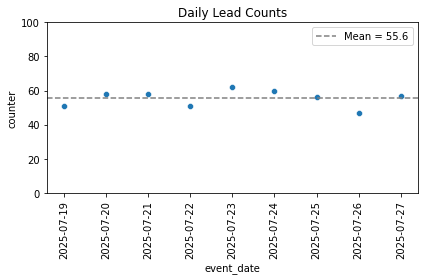

In [245]:
# Create scatterplot
ax = sns.scatterplot(data=daily_lead_ct, x="event_date", y="counter")

# Add mean line
mean_value = daily_lead_ct["counter"].mean()
ax.axhline(mean_value, color='grey', linestyle='--', label=f'Mean = {mean_value:.1f}')

# Customize plot
ax.set_ylim(0, 100)
ax.set_title("Daily Lead Counts")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend()
plt.show()

### AVG Lead Score by Date
- look at how the leads quality changes over time, to monitor if changes need to be made overall.

In [249]:
score_vs_date = df_leads.groupby("event_date")["lead_score"].mean().sort_index(ascending=True).to_frame()
score_vs_date.head(2)

,lead_score
event_date,
2025-07-19,49.803922
2025-07-20,50.344828


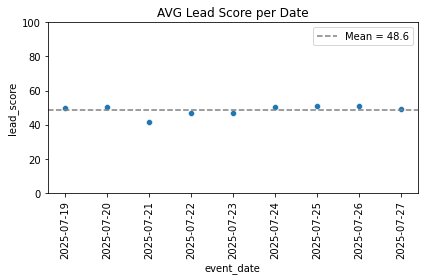

In [250]:

# Create scatterplot
ax = sns.scatterplot(data=score_vs_date, x="event_date", y="lead_score")

# Add mean line
mean_value = score_vs_date["lead_score"].mean()
ax.axhline(mean_value, color='grey', linestyle='--', label=f'Mean = {mean_value:.1f}')

# Customize plot
ax.set_ylim(0, 100)
ax.set_title("AVG Lead Score per Date")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend()
plt.show()

### AVG Lead Score by Traffic Source
- Organic, Facebook, Instagram, Tiktok, Email
- Look at which perform the best/worst and take action as needed

In [186]:
score_vs_source = df_leads.groupby("traffic_source")["lead_score"].mean().sort_values(ascending=False).to_frame()
score_vs_source

,lead_score
traffic_source,
organic,51.333333
facebook.com,50.924370
instagram.com,49.491525
tiktok.com,46.197183
email,44.918033


### AVG Lead Score by Campaign Type
- Social Media, grassroots1, grassroots2, grassroots3, grassroots4
- Look at which perform the best/worst and take action as needed

In [187]:
score_vs_campaign = df_leads.groupby("campaign_type")["lead_score"].mean().sort_values(ascending=False).to_frame()
score_vs_campaign

,lead_score
campaign_type,
social_media,50.133333
grassroots_4,48.169014
grassroots_2,48.000000
grassroots_1,47.887324
grassroots_3,45.000000


### AVG Lead Score by City
- Chicago, Aurora, Joliet, Naperville, Springfield
- Look at which perform the best/worst and take action as needed

In [202]:
score_vs_city = df_leads.groupby("city")["lead_score"].mean().sort_values(ascending=False).to_frame()
score_vs_city

,lead_score
city,
Springfield,50.679612
Joliet,49.787234
Aurora,48.543689
Naperville,47.326733
Chicago,46.464646


### AVG Lead Score by Device Type
- mobile, desktop
- Look at which perform the best/worst and take action as needed

In [189]:
score_vs_device = df_leads.groupby("device_type")["lead_score"].mean().sort_values(ascending=False).to_frame()
score_vs_device

,lead_score
device_type,
desktop,50.209205
mobile,47.049808


### Scatterplots comparing AVG Lead Scores by several categories
- Helps provide an general overview of which sources/campaigns/cities/devices performance, so action can be taken as needed.

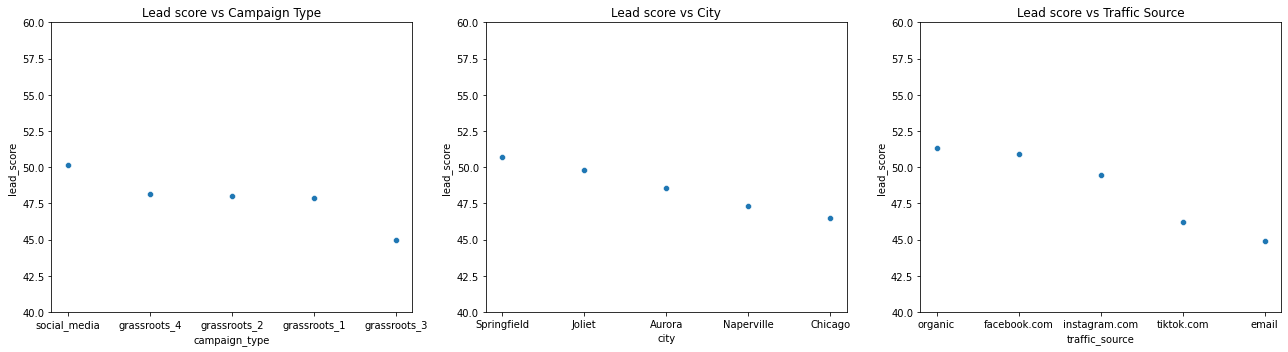

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure with 3 columns (1 row, 3 plots)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))  # adjust figsize as needed

# Scatter 1: lead_score vs campaign_type
sns.scatterplot(data=score_vs_campaign, x='campaign_type', y='lead_score', ax=axs[0])
axs[0].set_title("Lead score vs Campaign Type")
axs[0].set_ylim(40, 60)

# Scatter 2: lead_score vs city
sns.scatterplot(data=score_vs_city, x='city', y='lead_score', ax=axs[1])
axs[1].set_title("Lead score vs City")
axs[1].set_ylim(40, 60)

# Scatter 3: lead_score vs traffic_source
sns.scatterplot(data=score_vs_source, x='traffic_source', y='lead_score', ax=axs[2])
axs[2].set_title("Lead score vs Traffic Source")
axs[2].set_ylim(40, 60)

plt.tight_layout()
plt.show()


### Comments - Average score by categories:  

After running the AVG Lead Scores by Campaign Type, City, and Traffic Source the "email" traffic_source stands out as least effective lead generation method. 

NEXT ------> Heatmap: Let's now look at which campaigns had the most impact (highest average lead_score) on the 5 cities in scope.

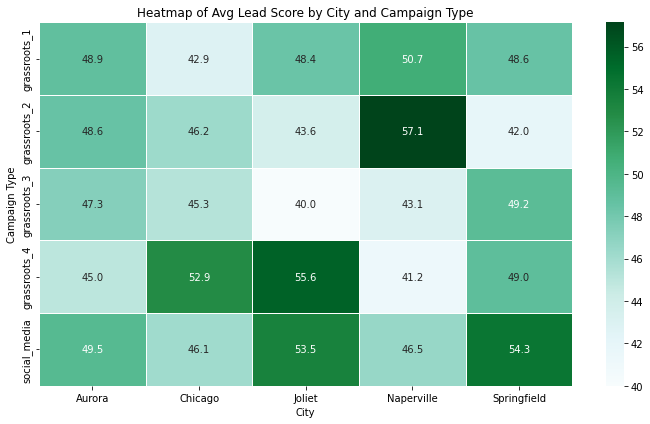

In [281]:
df_leads_heatmap = df_leads.groupby(['city', 'campaign_type'])['lead_score'].mean().reset_index()
heatmap_data = df_leads_heatmap.pivot(index='campaign_type', columns='city', values='lead_score')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='BuGn', linewidths=0.5)
plt.title('Heatmap of Avg Lead Score by City and Campaign Type')
plt.ylabel('Campaign Type')
plt.xlabel('City')
plt.tight_layout()
plt.show()

